# Predicting Medical Insurance Cost using Ensemble Methods

## Setup :

In [1]:
#Imports 

import sklearn
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [2]:
#Defining a space to save the figures 

PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Getting the Data :

In [3]:
HOUSING_PATH = os.path.join("datasets", "insurance.csv")

def load_insurance_data(housing_path=HOUSING_PATH):
    csv_path = housing_path
    return pd.read_csv(csv_path)

insurance = load_insurance_data()
print(insurance.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## Exploring and Visualizing the Data :

In [10]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Saving figure attribute_histogram_plots


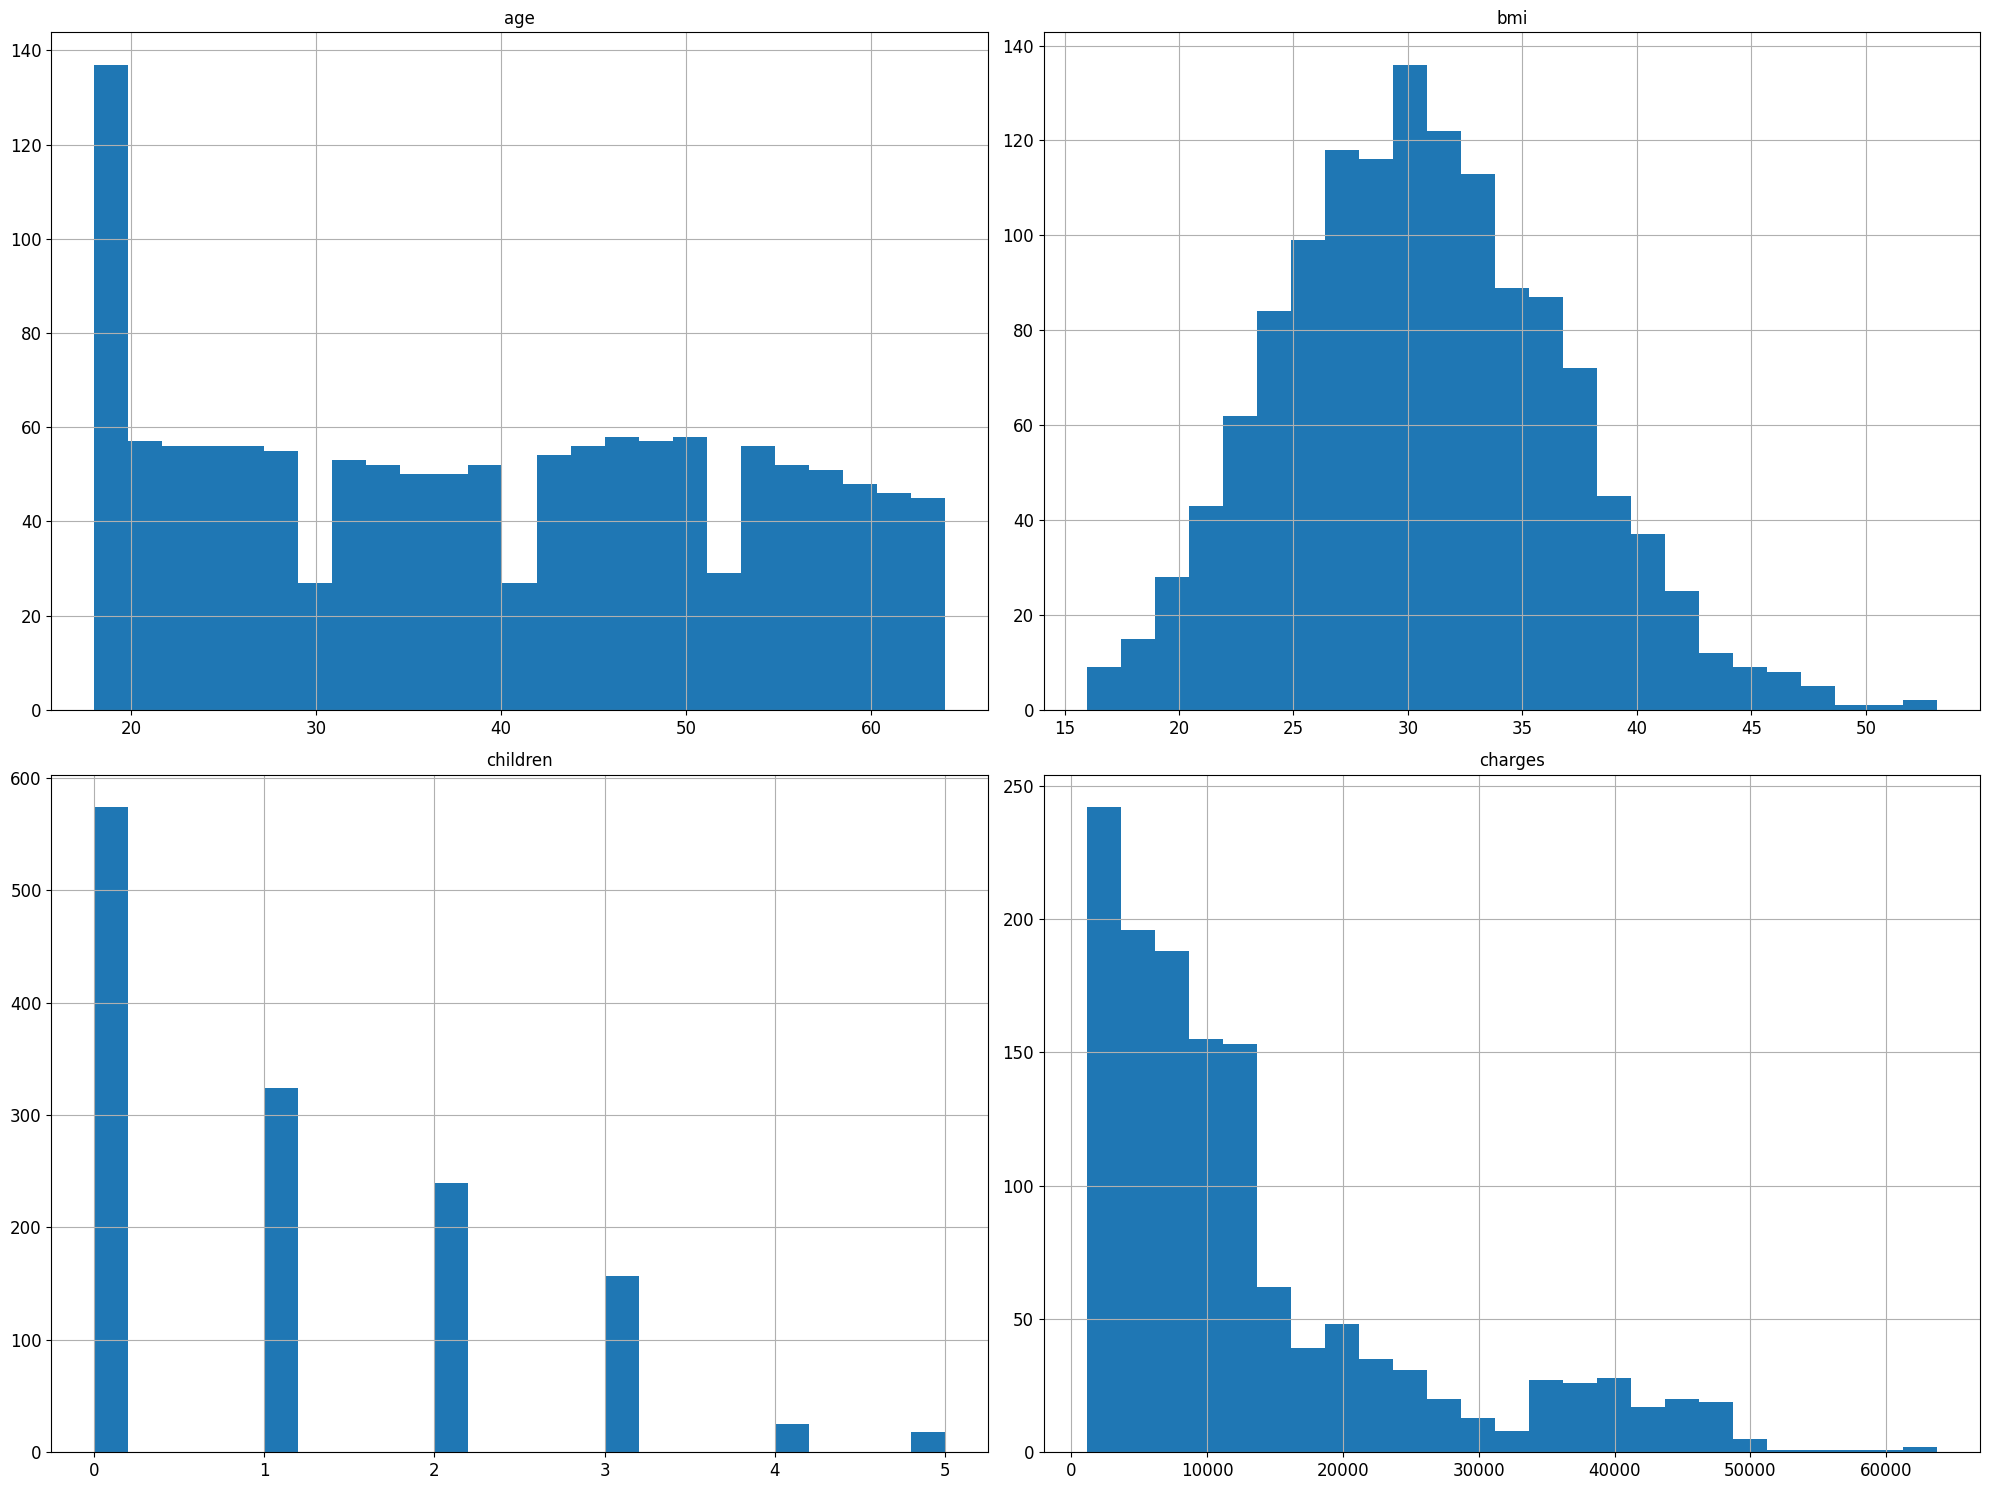

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
insurance.hist(bins=25, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

## Creating a Test Set :

In [16]:
# to make this notebook's output identical at every run
np.random.seed(42)

In [17]:
#Spliting the data into a train set and a test set
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(insurance, test_size=0.2, random_state=42)

In [18]:
test_set.head()

,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180


In [19]:
insurance = train_set.copy()

## Discover and Visualize the Data to Gain Insights

Saving figure visualization_charges_against_age


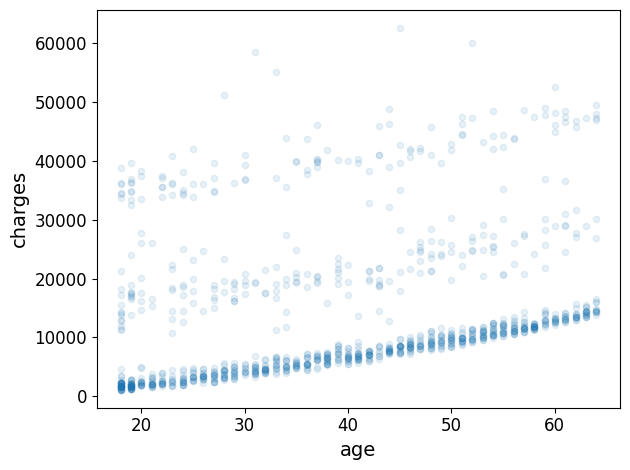

In [27]:
insurance.plot(kind="scatter",x="age",y="charges",alpha=0.1)
save_fig("visualization_charges_against_age")

## Looking for correlations :

In [43]:
#Identifying the numerical attributes
insurance_num = insurance[["age","bmi","children","charges"]]

In [44]:
#Correlations matrix
corr_matrix = insurance_num.corr()

In [45]:
corr_matrix["charges"].sort_values(ascending=False)

charges     1.000000
age         0.281721
bmi         0.197316
children    0.071885
Name: charges, dtype: float64

Saving figure scatter_matrix_plot


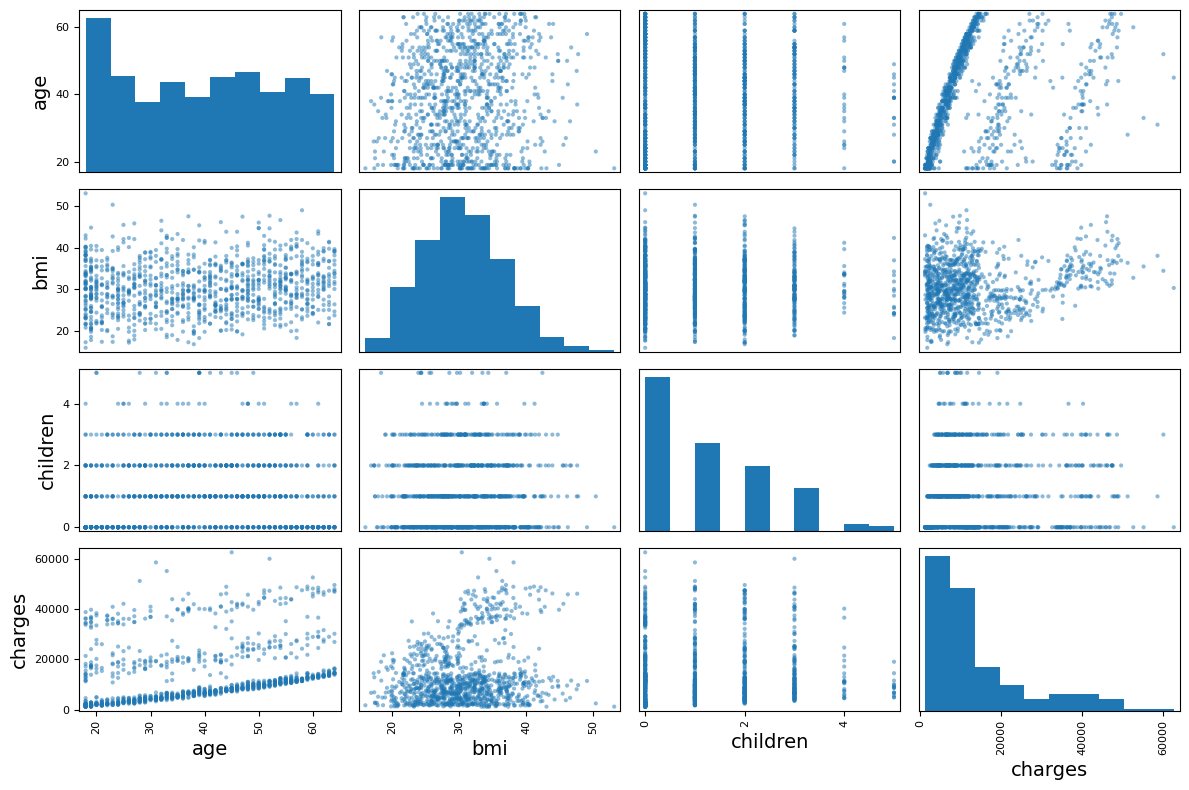

In [46]:
from pandas.plotting import scatter_matrix

scatter_matrix(insurance_num, figsize=(12, 8))
save_fig("scatter_matrix_plot")

__Remark__ : You can also experiment with new parameters by trying new combinations ; in our case the number of numeric attribute is too low so we wil not try to combine them. If the model is not performing good enough we can try to come back here to add other attributes with hiden correlation.

## Prepare the Training Data for ML Algorithms

In [70]:
insurance = train_set.drop("charges", axis=1) # drop labels for training set
insurance_num = insurance[["age","bmi","children"]]
insurance_labels = train_set["charges"].copy()

In [71]:
sample_incomplete_rows = insurance[insurance.isnull().any(axis=1)].head()
sample_incomplete_rows

,age,sex,bmi,children,smoker,region


__Remark__ : here we can see that the dataset is well constructed as there are no missing values ! 

__Other Remark__ : On a more serious note, we chose this dataset because it was easy to use. In reality the datasets are almost never complete and they require good amout of cleaning.

## Handling Text and Categorical Attributes :


In [72]:
#Identifying the non-numerical attributes / categorical attributes 
insurance_cat = insurance[["sex","smoker","region"]]
insurance_cat.head(10)

,sex,smoker,region
560,female,no,northwest
1285,female,no,northeast
1142,female,no,southeast
969,female,no,southeast
486,female,no,northwest
170,male,no,southeast
277,female,no,southwest
1033,male,yes,northeast
209,male,no,northeast
947,male,yes,northeast


In [73]:
#Using a OneHotEncoder to convert categorical attributes to numerical attributes 
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
insurance_cat_1hot = cat_encoder.fit_transform(insurance_cat)
insurance_cat_1hot

<1070x8 sparse matrix of type '<class 'numpy.float64'>'
	with 3210 stored elements in Compressed Sparse Row format>

In [74]:
cat_encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

## Custom Transformers :

Custom transformers are used to build custom cleaning operations or to combine specific attributes. Here we have too few attributes in the dataset, so we will try to continue without implementing new attributes. For illustration purposes this is what a custom transformer could look like :

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

## Tansformation Pipelines :

__Remark__ : The first pipeline (pipeline_num) is used to apply the needed transformations (handling missing values and scaling the values) on the numerical atrributes.
The second pipeline (full_pipeline) is used to combine the transformations on numerical attributes and the transformations on the categorical (or non numerical) attributes.

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])

insurance_num_tr = num_pipeline.fit_transform(insurance_num)

In [76]:
insurance_num_tr

array([[ 0.47222651, -1.75652513,  0.73433626],
       [ 0.54331294, -1.03308239, -0.91119211],
       [ 0.8987451 , -0.94368672, -0.91119211],
       ...,
       [ 1.3252637 , -0.89153925, -0.91119211],
       [-0.16755139,  2.82086429,  0.73433626],
       [ 1.1120044 , -0.10932713, -0.91119211]])

__Remark__ : Here the SimpleImputer() transformer is only there for illustration purposes. We already checked that there were no missing values in the dataset. If it was the case we could have used this method.

In [77]:
from sklearn.compose import ColumnTransformer

num_attribs = ["age","bmi","children"]
cat_attribs = list(insurance_cat)

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

insurance_prepared = full_pipeline.fit_transform(insurance)

In [78]:
insurance_prepared

array([[ 0.47222651, -1.75652513,  0.73433626, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.54331294, -1.03308239, -0.91119211, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.8987451 , -0.94368672, -0.91119211, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.3252637 , -0.89153925, -0.91119211, ...,  0.        ,
         0.        ,  0.        ],
       [-0.16755139,  2.82086429,  0.73433626, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.1120044 , -0.10932713, -0.91119211, ...,  0.        ,
         0.        ,  1.        ]])

In [79]:
insurance_prepared.shape

(1070, 11)

## Select and Train a Model :

Let's first try a linear regression :

In [80]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(insurance_prepared, insurance_labels)

LinearRegression()

In [81]:
# let's try the full preprocessing pipeline on a few training instances
some_data = insurance.iloc[:5]
some_labels = insurance_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [ 6656.  8704.  9216. 10752.  9536.]


In [82]:
print("Labels:", list(some_labels))

Labels: [9193.8385, 8534.6718, 27117.99378, 8596.8278, 12475.3513]


In [84]:
from sklearn.metrics import mean_squared_error

insurance_predictions = lin_reg.predict(insurance_prepared)
lin_mse = mean_squared_error(insurance_labels, insurance_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

6113.551151636188

In [85]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(insurance_labels, insurance_predictions)
lin_mae

4282.680959299066

Let's now try a Decision Tree Regressor :

In [86]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(insurance_prepared, insurance_labels)

DecisionTreeRegressor(random_state=42)

In [87]:
insurance_predictions = tree_reg.predict(insurance_prepared)
tree_mse = mean_squared_error(insurance_labels, insurance_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse


494.20598375812835

## Better Evaluation Using Cross-Validation :

In [89]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, insurance_prepared, insurance_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [6339.58900717 6578.46280707 7070.94331065 7082.71162807 7035.35755633
 6537.63856176 7436.65224436 7411.85619806 6621.32660141 5569.81488004]
Mean: 6768.4352794914985
Standard deviation: 534.1938075533002


In [90]:
lin_scores = cross_val_score(lin_reg, insurance_prepared, insurance_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [6088.62821183 6579.03828457 5218.86367097 6042.09621288 5843.70905614
 6177.20119308 7212.64087053 6318.98648379 6191.88536253 5669.09794393]
Mean: 6134.214729025356
Standard deviation: 504.9102849483168


Let's now try a Random Forest Regressor : it works by training many Decision Trees on random subsets of the features, then averaging out their predictions. 

In [92]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(insurance_prepared, insurance_labels)

insurance_predictions = forest_reg.predict(insurance_prepared)
forest_mse = mean_squared_error(insurance_labels, insurance_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

1900.9799788695125

Let's get the CV Score for the Random Forest Regressor :

In [93]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, insurance_prepared, insurance_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [4837.88091145 5321.29233914 3855.38071452 4444.14090314 5283.52272899
 4882.71894641 5656.0522389  5424.90384931 5177.82380257 4687.58891207]
Mean: 4957.130534650082
Standard deviation: 506.4164192696564


 Conclusion : the Random Forest Regressor seems to be the best performing model.

## Fine-tune the selected model (Random Forest Regressor) :

In [94]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 3, 4, 5]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(insurance_prepared, insurance_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 3, 4, 5],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [95]:
grid_search.best_params_

{'max_features': 5, 'n_estimators': 30}

In [96]:
grid_search.best_estimator_

RandomForestRegressor(max_features=5, n_estimators=30, random_state=42)

In [97]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

5869.472669568795 {'max_features': 2, 'n_estimators': 3}
5344.09974595216 {'max_features': 2, 'n_estimators': 10}
5043.721468813344 {'max_features': 2, 'n_estimators': 30}
5648.138086537294 {'max_features': 3, 'n_estimators': 3}
5105.500999588195 {'max_features': 3, 'n_estimators': 10}
4893.003223784434 {'max_features': 3, 'n_estimators': 30}
5408.495942571259 {'max_features': 4, 'n_estimators': 3}
4917.741867902749 {'max_features': 4, 'n_estimators': 10}
4819.911075212028 {'max_features': 4, 'n_estimators': 30}
5329.890795940145 {'max_features': 5, 'n_estimators': 3}
4945.846057937126 {'max_features': 5, 'n_estimators': 10}
4791.773863128718 {'max_features': 5, 'n_estimators': 30}
5824.642078297096 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
5360.687013306672 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
5590.669350674112 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
5215.110265030829 {'bootstrap': False, 'max_features': 3, 'n_estimators': 10}

In [98]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([0.14203938, 0.18778845, 0.02184478, 0.00542714, 0.00411807,
       0.27403738, 0.34359555, 0.00547049, 0.00498177, 0.00657547,
       0.00412152])

In [99]:
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(0.18778844973966602, 'bmi'),
 (0.14203937513086864, 'age'),
 (0.02184477637216532, 'children'),
 (0.005427140684887419, 'female'),
 (0.004118072604870407, 'male')]

## Evaluation of the Model on the Test Set :

We are now going to test our model on the test set ! Because our problem is a regression problem, we have to measure the accuracy of our model with the RMSE (Root Mean Squared Error). Let's see how our model is doing :

In [101]:
final_model = grid_search.best_estimator_

X_test = test_set.drop("charges", axis=1)
y_test = test_set["charges"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

final_rmse

4592.411834803969

We can also compute a 95% confidence interval for the test RMSE :

In [102]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([3615.44349268, 5395.28138953])